In [1]:
import h5py
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio; pio.renderers.default = 'notebook'

In [2]:
f = h5py.File('data/packet-0050017-2024_07_09_00_04_33_CDT.FLOW.hdf5')

In [3]:
f.keys()

<KeysViewHDF5 ['charge', 'combined', 'geometry_info', 'lar_info', 'light', 'run_info']>

In [4]:
f['charge']

<HDF5 group "/charge" (9 members)>

In [5]:
f['charge'].keys()

<KeysViewHDF5 ['calib_final_hits', 'calib_prompt_hits', 'events', 'ext_trigs', 'packets', 'packets_corr_ts', 'pps_delay', 'raw_events', 'raw_hits']>

In [6]:
f['charge/events']

<HDF5 group "/charge/events" (2 members)>

In [7]:
f['charge/events'].keys()

<KeysViewHDF5 ['data', 'ref']>

In [8]:
f['charge/events/data']

<HDF5 dataset "data": shape (9072,), type "|V52">

In [9]:
f['charge/events/data'].dtype

dtype([('id', '<u8'), ('nhit', '<u4'), ('ADC', '<f8'), ('ts_start', '<f8'), ('ts_end', '<f8'), ('n_ext_trigs', '<u4'), ('unix_ts', '<u8'), ('unix_ts_usec', '<u4')])

In [10]:
events = f['charge/events/data']

In [11]:
events[:10]

array([(0, 12,  414., 1185851.3238609 , 1187641., 1, 1720501473, 301160),
       (1, 12,  389., 1484462.39816657, 1486037., 1, 1720501473, 331021),
       (2,  8,  236., 2062731.60553202, 2064589., 1, 1720501473, 388848),
       (3,  8,  237., 2140993.        , 2142909., 1, 1720501473, 396674),
       (4, 11,  335., 2287874.        , 2289790., 1, 1720501473, 411362),
       (5, 11,  346., 3875702.98532075, 3877602., 1, 1720501473, 570145),
       (6, 16,  482., 4826093.        , 4827991., 1, 1720501473, 665184),
       (7, 25,  795., 5594126.        , 5595964., 1, 1720501473, 741987),
       (8, 42, 1288., 5704890.        , 5707542., 0, 1720501473, 753064),
       (9, 38, 1203., 6220944.        , 6223442., 0, 1720501473, 804669)],
      dtype=[('id', '<u8'), ('nhit', '<u4'), ('ADC', '<f8'), ('ts_start', '<f8'), ('ts_end', '<f8'), ('n_ext_trigs', '<u4'), ('unix_ts', '<u8'), ('unix_ts_usec', '<u4')])

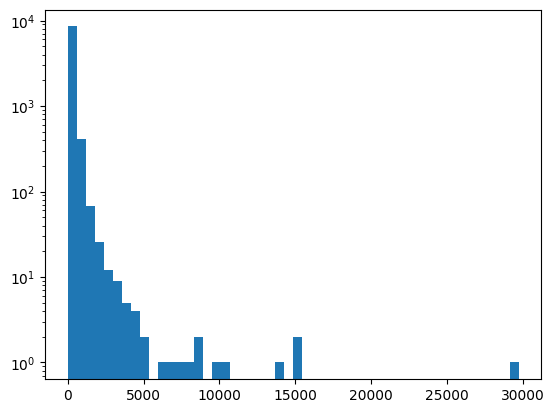

In [12]:
plt.hist(events['nhit'], bins=50);
plt.yscale('log');

In [13]:
a_few_events = events[:5]

In [14]:
a_few_events

array([(0, 12, 414., 1185851.3238609 , 1187641., 1, 1720501473, 301160),
       (1, 12, 389., 1484462.39816657, 1486037., 1, 1720501473, 331021),
       (2,  8, 236., 2062731.60553202, 2064589., 1, 1720501473, 388848),
       (3,  8, 237., 2140993.        , 2142909., 1, 1720501473, 396674),
       (4, 11, 335., 2287874.        , 2289790., 1, 1720501473, 411362)],
      dtype=[('id', '<u8'), ('nhit', '<u4'), ('ADC', '<f8'), ('ts_start', '<f8'), ('ts_end', '<f8'), ('n_ext_trigs', '<u4'), ('unix_ts', '<u8'), ('unix_ts_usec', '<u4')])

In [15]:
a_few_events[[False, True, False, True, False]]

array([(1, 12, 389., 1484462.39816657, 1486037., 1, 1720501473, 331021),
       (3,  8, 237., 2140993.        , 2142909., 1, 1720501473, 396674)],
      dtype=[('id', '<u8'), ('nhit', '<u4'), ('ADC', '<f8'), ('ts_start', '<f8'), ('ts_end', '<f8'), ('n_ext_trigs', '<u4'), ('unix_ts', '<u8'), ('unix_ts_usec', '<u4')])

In [16]:
a_few_events['nhit'] > 10

array([ True,  True, False, False,  True])

In [17]:
cool_events = events[events['nhit'] >= 2500]

In [18]:
cool_events

array([(  74,  6724, 249452., 6879029.30565018, 6880966., 1, 1720501478, 870478),
       ( 239, 10607, 327800., 5905874.        , 5907823., 1, 1720501488, 773162),
       ( 268,  3829, 143864., 6926782.        , 6928748., 1, 1720501490, 875253),
       ( 664,  3749, 151597., 5037890.        , 5039841., 1, 1720501513, 686364),
       (1189,  3179, 121654., 7821414.703595  , 7823344., 1, 1720501548, 964716),
       (1395, 29695, 730071., 4586852.78075638, 4588796., 1, 1720501562, 641260),
       (1769, 13994, 513751., 8547765.4687987 , 8549703., 1, 1720501589,  37351),
       (2009,  4342, 161109., 1233804.        , 1238954., 0, 1720501603, 305955),
       (2041,  4069, 140187., 6570971.82934789, 6572905., 1, 1720501605, 839672),
       (2383,  4654, 176773., 2541126.68008464, 2543060., 1, 1720501627, 436687),
       (2676,  3167, 117563., 3187277.        , 3189186., 1, 1720501649, 501302),
       (2917,  2935, 115223., 9179206.        , 9181201., 1, 1720501665, 100495),
       (3013,  6

In [19]:
def value_to_color(v, vmin, vmax, colorscale):
    t = 0 if vmax == vmin else (v - vmin) / (vmax - vmin)
    idx = int(round(t * (len(colorscale) - 1)))
    return colorscale[idx]

def plot_evt(evt):
    refs = f['charge/events/ref/charge/calib_prompt_hits/ref']
    idcs = refs[refs[:,0] == evt][:,1]
    hits = f['charge/calib_prompt_hits/data'][idcs]

    colorscale = px.colors.sequential.Viridis
    vmin, vmax = hits['Q'].min(), hits['Q'].max()

    fig = go.Figure()
    trace = go.Scatter3d(x=hits['x'], y=hits['y'], z=hits['z'], mode='markers',
                        marker=dict(color=hits['Q'], colorscale=colorscale))
    fig.add_trace(trace)
    fig.update_layout(
        title=f'Hits',
        scene=dict(
            xaxis_title='X',
            yaxis_title='Y',
            zaxis_title='Z',
            aspectmode='data'
    ))
    fig.show()
    return hits

In [22]:
plot_evt(7293)

array([(965758,  61.2388447 , -32.14649963, -61.65589905,  168., 9953632, 3, 28, 101, 45, 16.19012475, 16.19012475,  0.54438438, False),
       (965759,  13.40495246, -28.59930038, -63.8728981 ,  645., 9954109, 4, 24, 101,  5,  3.25064753,  3.25064753,  0.1093013 , False),
       (965760,  54.30013553, -29.04269981, -59.43889999,  601., 9954065, 3, 17,  12, 43,  8.27791614,  8.27791614,  0.27834055, False),
       ...,
       (968371, -24.10947376, -39.24089813, -25.29710007, 1313., 9954777, 7, 19,  38, 18, -2.84861122, -2.61797324, -0.08802797, False),
       (968372, -28.468201  , -39.24089813, -25.29710007, 1585., 9955049, 7, 19,  38, 18, -2.84861122, -2.6012063 , -0.08746419, False),
       (968373, -32.8589777 , -39.24089813, -25.29710007, 1859., 9955323, 7, 19,  38, 18, -0.96562941, -0.71199731, -0.02394053, False)],
      shape=(2616,), dtype=[('id', '<u4'), ('x', '<f8'), ('y', '<f8'), ('z', '<f8'), ('t_drift', '<f8'), ('ts_pps', '<u8'), ('io_group', '<u8'), ('io_channel', '<u8'

In [21]:
fig = go.Figure()
fig.add_trace(go.Scatter3d(x=[1,2,3],y=[4,5,6],z=[7,8,9]))
fig.show()